In [1]:
print("done")

done


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

# Base directory where the dataset is mounted
base_dir = "/kaggle/input/sicapv2"

# Check directory structure
for root, dirs, files in os.walk(base_dir):
    print(f"{root} -> {len(files)} files")


/kaggle/input/sicapv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2 -> 2 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/images -> 18783 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val3 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val4 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val2 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val1 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Test -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks -> 18783 files


In [3]:
import os

image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
print("Files in images dir:", os.listdir(image_dir)[:5])


Files in images dir: ['16B0006669_Block_Region_24_6_2_xini_14275_yini_13598.jpg', '18B0005230E_Block_Region_5_11_23_xini_38257_yini_96363.jpg', '18B0006621D_Block_Region_2_1_13_xini_21582_yini_66086.jpg', '18B0006177A_Block_Region_2_6_19_xini_51693_yini_147491.jpg', '16B0022612_Block_Region_1_20_12_xini_15667_yini_92428.jpg']


Total images found: 18783
✅ Found matching image + mask for: 16B0003394_Block_Region_3_3_4_xini_11071_yini_48003.jpg
Image shape: (512, 512, 3)
Mask shape: (512, 512)
Unique values in mask: [0]


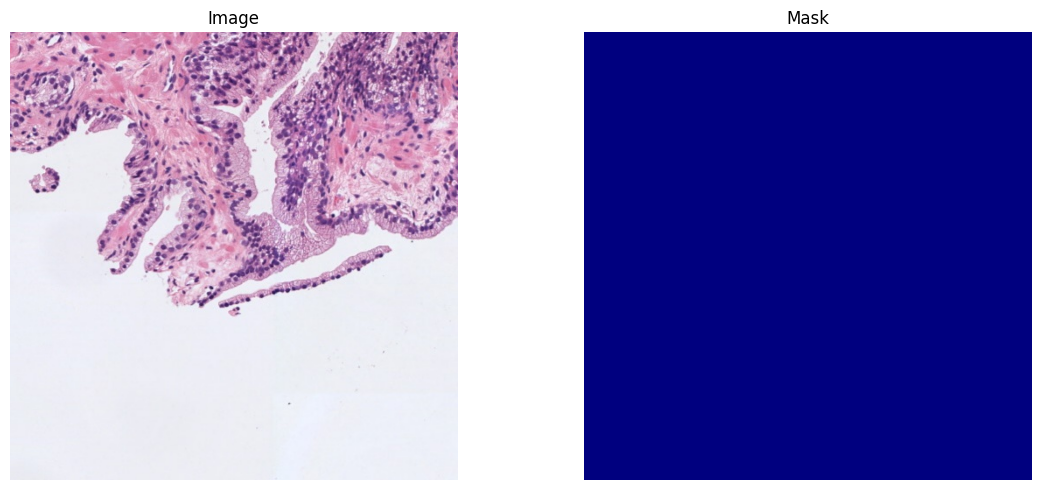

In [4]:
import random
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

# Correct image and mask directories
image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
mask_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks"

# Get list of image files
image_paths = glob(os.path.join(image_dir, "*.jpg"))
print(f"Total images found: {len(image_paths)}")

# Try loading image-mask pair
for _ in range(20):
    sample_image_path = random.choice(image_paths)
    filename = os.path.basename(sample_image_path)
    sample_mask_path = os.path.join(mask_dir, filename)  # No extension change now

    if os.path.exists(sample_mask_path):
        print("✅ Found matching image + mask for:", filename)
        break
else:
    raise FileNotFoundError("No matching masks found for any image.")

# Load image and mask
image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# Print some sanity info
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Unique values in mask:", np.unique(mask))

# Show image and mask
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='jet')
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# Path to Excel label file
xlsx_path = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx"

# Read Excel
df = pd.read_excel(xlsx_path)

# Your GG logic
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"

df["GG"] = df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

print(df.head())
print(df["GG"].value_counts())


     slide_id  patient_id  Gleason_primary  Gleason_secondary   GG
0  16B0001851      667360                4                  5  GG5
1  16B0003388      325687                4                  4  GG4
2  16B0003394      747184                3                  3   NC
3  16B0006668       14107                5                  5  GG5
4  16B0006669       14107                5                  5  GG5
GG
NC     72
GG5    42
GG3    23
GG4    18
Name: count, dtype: int64


In [6]:
from glob import glob
import pandas as pd
import os

# Load GG labels
labels_df = pd.read_excel("/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx")
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"
labels_df["GG"] = labels_df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

# Create a dictionary for quick lookup
slideid_to_gg = dict(zip(labels_df["slide_id"].astype(str), labels_df["GG"]))

# Grab all patch image paths
patch_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
patch_paths = glob(os.path.join(patch_dir, "*.jpg"))

# Build dataframe with patch paths and labels
patch_data = []
for path in patch_paths:
    filename = os.path.basename(path)
    slide_id = filename.split("_")[0]
    if slide_id in slideid_to_gg:
        label = slideid_to_gg[slide_id]
        patch_data.append((path, label))

# Create final dataframe
patch_df = pd.DataFrame(patch_data, columns=["path", "label"])
print("Total labeled patches:", len(patch_df))
print(patch_df["label"].value_counts())
patch_df.head()


Total labeled patches: 18783
label
NC     7995
GG5    5654
GG3    3082
GG4    2052
Name: count, dtype: int64


,path,label
0,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
1,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC
2,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG3
3,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
4,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC


In [7]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [8]:
from sklearn.model_selection import train_test_split

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    patch_df, test_size=0.2, stratify=patch_df["label"], random_state=42)

# Second split: val vs test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 15026 | Val: 1878 | Test: 1879


In [9]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [10]:
# ---------------- Imports ----------------
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import densenet169, DenseNet169_Weights
from torchvision.models import swin_t, Swin_T_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm


In [14]:
from timm import create_model
vit = create_model('vit_base_patch16_224', pretrained=True).to(device)
vit.eval()


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [15]:
# Cell 1: Load DenseNet-169 and ViT (timm), remove heads, helper functions
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm import create_model
from torchvision.models import densenet169, DenseNet169_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- DenseNet-169 (torchvision) ----
densenet = densenet169(weights=DenseNet169_Weights.IMAGENET1K_V1)
# We'll call densenet.features(...) to get conv feature map, don't rely on model(dummy) since classifier may be different.
densenet = densenet.to(device)
densenet.eval()

# ---- ViT (timm) ----
# Using timm: 'vit_base_patch16_224' is a standard ViT that expects 224x224
vit = create_model('vit_base_patch16_224', pretrained=True)
# timm models typically have forward_features; keep the model as-is and we'll use forward_features if present
vit = vit.to(device)
vit.eval()

# ---- Helper: robust feature extraction for dynamic dim calc ----
def extract_backbone_features(model, x):
    """
    Returns a 2D tensor [B, C] of backbone features for classification.
    Handles 4D conv outputs (apply GAP), 3D token outputs (take CLS or mean), or direct 2D outputs.
    """
    # Prefer explicit feature methods used by model libraries
    if hasattr(model, "forward_features"):
        out = model.forward_features(x)  # timm ViT & some timm models
    elif hasattr(model, "features"):
        out = model.features(x)  # torchvision DenseNet returns 4D conv feature map
    else:
        out = model(x)

    # unwrap tuples
    if isinstance(out, tuple):
        out = out[0]

    # If conv feature map -> [B, C, H, W] -> GAP -> [B, C]
    if out.dim() == 4:
        out = F.adaptive_avg_pool2d(out, (1, 1)).flatten(1)
    # If token sequence -> [B, S, C] -> usually CLS at index 0
    elif out.dim() == 3:
        # If it's like [B, seq_len, dim], prefer CLS token
        out = out[:, 0, :]  # safe for timm.vit forward_features
    else:
        out = out.flatten(1)

    return out

# ---- Quick check: compute feature dims (dummy) ----
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    dfeat = extract_backbone_features(densenet, dummy)
    vfeat = extract_backbone_features(vit, dummy)
    print("DenseNet feature dim:", dfeat.shape)
    print("ViT feature dim:", vfeat.shape)

DENSENET_FEAT_DIM = dfeat.shape[1]
VIT_FEAT_DIM = vfeat.shape[1]


Using device: cuda
DenseNet feature dim: torch.Size([1, 1664])
ViT feature dim: torch.Size([1, 768])


In [24]:
# Cell 2: AFAModule + DenseVit fusion model
import math

class AFAModule(nn.Module):
    def __init__(self, dim1, dim2, reduction=16, out_dim=None):
        super().__init__()
        if out_dim is None:
            out_dim = max(dim1, dim2)  # project both to bigger space
        
        self.proj1 = nn.Linear(dim1, out_dim)
        self.proj2 = nn.Linear(dim2, out_dim)

        inner = max(8, out_dim // reduction)
        self.fc1 = nn.Linear(out_dim, inner)
        self.fc2 = nn.Linear(out_dim, inner)
        self.fc3 = nn.Linear(inner * 2, out_dim)
        self.act = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x1, x2):
        # project both
        x1 = self.proj1(x1)
        x2 = self.proj2(x2)

        y1 = self.act(self.fc1(x1))
        y2 = self.act(self.fc2(x2))
        y = torch.cat([y1, y2], dim=1)
        att = self.sigmoid(self.fc3(y))

        fused = x1 * att + x2 * (1 - att)   # attention-based fusion
        return fused

class DenseVitAFA(nn.Module):
    def __init__(self, densenet_backbone, vit_backbone, densenet_dim, vit_dim, num_classes=4):
        super().__init__()
        self.densenet = densenet_backbone
        self.vit = vit_backbone
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.afa = AFAModule(densenet_dim, vit_dim, reduction=16, out_dim=1024)  # project both into 1024
        fused_dim = 1024

        # classifier: small MLP with dropout option
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(fused_dim // 2, num_classes)
        )


    def forward(self, x):
        # DenseNet conv features
        if hasattr(self.densenet, "features"):
            f1 = self.densenet.features(x)
            f1 = F.relu(f1, inplace=True)
            f1 = F.adaptive_avg_pool2d(f1, (1, 1)).flatten(1)
        else:
            # fallback
            f1 = extract_backbone_features(self.densenet, x)

        # ViT features: ensure input size is 224x224
        if hasattr(self.vit, "forward_features"):
            f2 = self.vit.forward_features(x)  # timm ViT returns token CLS embedding
            if f2.dim() == 3:
                f2 = f2[:, 0, :]
        else:
            f2 = extract_backbone_features(self.vit, x)

        # fuse with AFA
        fused = self.afa(f1, f2)
        out = self.classifier(fused)
        return out


In [25]:
# Cell 3: Instantiate model & optim setup
num_classes = 4  # NC, GG3, GG4, GG5

# instantiate
model = DenseVitAFA(densenet_backbone=densenet,
                     vit_backbone=vit,
                     densenet_dim=DENSENET_FEAT_DIM,
                     vit_dim=VIT_FEAT_DIM,
                     num_classes=num_classes).to(device)

# Optionally freeze some backbone layers (light fine-tuning). Here: lower lr for backbones.
backbone_params = list(model.densenet.parameters()) + list(model.vit.parameters())
head_params = list(model.classifier.parameters()) + list(model.afa.parameters())

optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=1e-5)

criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

ckpt_dir = "./fusion_checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)
best_val_acc = 0.0

print("Model and optimizer ready. Total params:", sum(p.numel() for p in model.parameters()))


Model and optimizer ready. Total params: 103999700


In [26]:
# Cell 4: Data transforms and DataLoaders (uses train_df, val_df, test_df if present)
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

# If train/val/test already exist in the notebook, we'll use them; otherwise split patch_df
try:
    _ = train_df  # noqa
    print("Using existing train_df/val_df/test_df provided in the notebook.")
except NameError:
    print("train_df not found — creating train/val/test splits from patch_df")
    # patch_df expected to exist (you created it earlier)
    if 'patch_df' not in globals():
        raise RuntimeError("patch_df not found in workspace. Run earlier cell that builds patch_df first.")
    train_df, temp_df = train_test_split(patch_df, test_size=0.2, stratify=patch_df["label"], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

# Dataset class (safe self-contained)
label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}
class PatchDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        label = label_to_idx[self.df.loc[idx, "label"]]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# Transforms: use 224x224 for both backbones
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.15,0.15,0.15,0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

batch_size = 16

train_dataset = PatchDataset(train_df, transform=train_transform)
val_dataset   = PatchDataset(val_df, transform=val_transform)
test_dataset  = PatchDataset(test_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"DataLoaders ready — train {len(train_loader)} batches | val {len(val_loader)} | test {len(test_loader)}")


Using existing train_df/val_df/test_df provided in the notebook.
DataLoaders ready — train 940 batches | val 118 | test 118


In [27]:
# Cell 5: Training loop (AMP) + scheduler + checkpointing
import time
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

num_epochs = 10
scaler = GradScaler()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    t0 = time.time()

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} — Train", ncols=100)
    for imgs, labels in loop:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item() * labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=f"{(correct/total):.4f}")

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} — Val", ncols=100):
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_loss += loss.item() * labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    print(f"\nEpoch {epoch} done in {time.time()-t0:.1f}s -> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epoch},
                   os.path.join(ckpt_dir, "best_dense_vit_afa.pth"))
        print("✅ Best checkpoint saved!")


/tmp/ipykernel_36/549563647.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/10 — Train:   0%|                                                   | 0/940 [00:00<?, ?it/s]/tmp/ipykernel_36/549563647.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10 — Val:   0%|                                                     | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_36/549563647.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10 — Val: 100%|███████████████████████████████████████████| 118/118 [00:10<00:00, 10.91it/s]



Epoch 1 done in 298.4s -> Train Loss: 0.9232 | Train Acc: 0.6376 | Val Loss: 0.7477 | Val Acc: 0.7109
✅ Best checkpoint saved!


Epoch 2/10 — Val: 100%|███████████████████████████████████████████| 118/118 [00:10<00:00, 11.25it/s]



Epoch 2 done in 297.1s -> Train Loss: 0.6768 | Train Acc: 0.7414 | Val Loss: 0.5566 | Val Acc: 0.7875
✅ Best checkpoint saved!


Epoch 3/10 — Val: 100%|███████████████████████████████████████████| 118/118 [00:10<00:00, 11.24it/s]


...


Epoch 8 done in 293.9s -> Train Loss: 0.0653 | Train Acc: 0.9768 | Val Loss: 0.1855 | Val Acc: 0.9430
✅ Best checkpoint saved!


Epoch 9/10 — Val: 100%|███████████████████████████████████████████| 118/118 [00:10<00:00, 11.23it/s]



Epoch 9 done in 292.9s -> Train Loss: 0.0471 | Train Acc: 0.9840 | Val Loss: 0.1766 | Val Acc: 0.9473
✅ Best checkpoint saved!


Epoch 10/10 — Val: 100%|██████████████████████████████████████████| 118/118 [00:10<00:00, 11.30it/s]



Epoch 10 done in 293.1s -> Train Loss: 0.0344 | Train Acc: 0.9878 | Val Loss: 0.1711 | Val Acc: 0.9515
✅ Best checkpoint saved!


In [28]:
# Load best checkpoint
ckpt_path = os.path.join(ckpt_dir, "best_dense_vit_afa.pth")
checkpoint = torch.load(ckpt_path, map_location=device)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer'])
start_epoch = checkpoint['epoch'] + 1

print(f"✅ Loaded best checkpoint from epoch {checkpoint['epoch']}")

# Train for 5 more epochs
extra_epochs = 5
for epoch in range(start_epoch, start_epoch + extra_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{start_epoch+extra_epochs-1} — Train", ncols=100)
    for imgs, labels in loop:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item() * labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=f"{(correct/total):.4f}")

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{start_epoch+extra_epochs-1} — Val", ncols=100):
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_loss += loss.item() * labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    print(f"\nEpoch {epoch} done in {time.time()-t0:.1f}s "
          f"-> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save if better
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'epoch': epoch},
                   ckpt_path)
        print("✅ Best checkpoint updated!")


✅ Loaded best checkpoint from epoch 10


Epoch 11/15 — Train:   0%|                                                  | 0/940 [00:00<?, ?it/s]/tmp/ipykernel_36/592180199.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 11/15 — Val:   0%|                                                    | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_36/592180199.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 11/15 — Val: 100%|██████████████████████████████████████████| 118/118 [00:10<00:00, 11.23it/s]



Epoch 11 done in 307.5s -> Train Loss: 0.0364 | Train Acc: 0.9878 | Val Loss: 0.1722 | Val Acc: 0.9521
✅ Best checkpoint updated!


Epoch 12/15 — Val: 100%|██████████████████████████████████████████| 118/118 [00:10<00:00, 11.21it/s]



Epoch 12 done in 306.5s -> Train Loss: 0.0300 | Train Acc: 0.9890 | Val Loss: 0.1659 | Val Acc: 0.9526
✅ Best checkpoint updated!


...


Epoch 13 done in 305.9s -> Train Loss: 0.0384 | Train Acc: 0.9862 | Val Loss: 0.1826 | Val Acc: 0.9483


Epoch 14/15 — Val: 100%|██████████████████████████████████████████| 118/118 [00:10<00:00, 11.25it/s]



Epoch 14 done in 307.0s -> Train Loss: 0.0434 | Train Acc: 0.9850 | Val Loss: 0.1686 | Val Acc: 0.9505


Epoch 15/15 — Val: 100%|██████████████████████████████████████████| 118/118 [00:10<00:00, 11.24it/s]


Epoch 15 done in 306.5s -> Train Loss: 0.0621 | Train Acc: 0.9780 | Val Loss: 0.1819 | Val Acc: 0.9462


✅ Loaded best checkpoint: ./fusion_checkpoints/best_dense_vit_afa.pth


Testing:   0%|                                                              | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_36/2100979939.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # AMP for consistency
Testing: 100%|████████████████████████████████████████████████████| 118/118 [00:10<00:00, 11.21it/s]



📊 Test Results -> Loss: 0.1304 | Acc: 0.9596

🔎 Classification Report:
              precision    recall  f1-score   support

          NC       0.95      0.98      0.97       800
         GG3       0.98      0.90      0.94       308
         GG4       0.95      0.92      0.94       205
         GG5       0.96      0.97      0.97       566

    accuracy                           0.96      1879
   macro avg       0.96      0.94      0.95      1879
weighted avg       0.96      0.96      0.96      1879



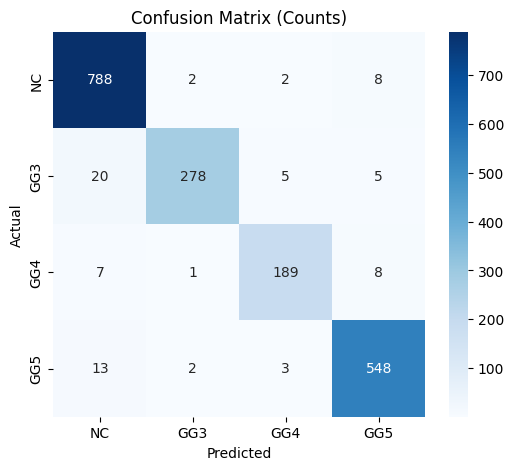

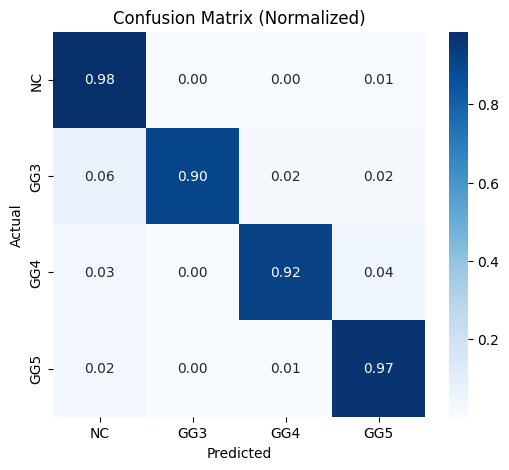

In [31]:
# Cell 6: Load best checkpoint and evaluate on test set
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.cuda.amp import autocast

# load best if exists
ckpt_path = os.path.join(ckpt_dir, "best_dense_vit_afa.pth")
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print("✅ Loaded best checkpoint:", ckpt_path)
else:
    print("⚠️ No saved checkpoint found — using current model weights for testing.")

model.eval()
all_preds, all_labels = [], []
test_loss, test_total, test_correct = 0.0, 0, 0

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing", ncols=100):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with autocast():  # AMP for consistency
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        test_loss += loss.item() * labels.size(0)

# Final metrics
test_loss = test_loss / test_total
test_acc = test_correct / test_total
print(f"\n📊 Test Results -> Loss: {test_loss:.4f} | Acc: {test_acc:.4f}\n")

# Classification report
print("🔎 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["NC","GG3","GG4","GG5"]))

# Confusion Matrix (raw counts)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NC","GG3","GG4","GG5"],
            yticklabels=["NC","GG3","GG4","GG5"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts)")
plt.show()

# Confusion Matrix (normalized)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["NC","GG3","GG4","GG5"],
            yticklabels=["NC","GG3","GG4","GG5"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Normalized)")
plt.show()


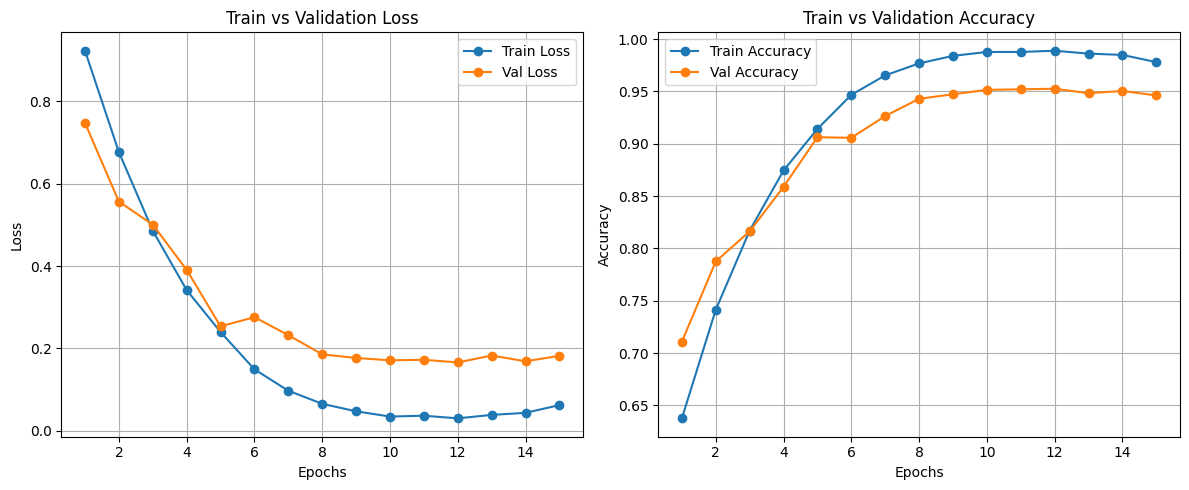

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Val Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Val Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
